# Análisis modular del TP1

Este notebook ejecuta el flujo de análisis por celdas y es compatible con VS Code, Jupyter y Google Colab.

**Archivo de entrada:** `datos_TP1_2025.csv`

## 1. Crear el notebook y seleccionar el kernel

En VS Code o Colab, seleccioná un kernel de Python válido antes de ejecutar las celdas. Los resultados quedarán embebidos en este archivo `.ipynb`.

## 2. Instalar y validar dependencias

Ejecutá esta celda solo si el entorno no tiene `pandas` o `matplotlib` instalados. En Google Colab normalmente ya están disponibles.

In [3]:
%pip install plotly nbformat statsmodels

You should consider upgrading via the '/Users/diegorojas/Documents/github projects/aa-tp-1/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [4]:
import sys
from pathlib import Path
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge, LassoCV, RidgeCV, ElasticNet, ElasticNetCV
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, log_loss, confusion_matrix, f1_score
from sklearn.metrics import classification_report
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

sys.path.append(str(Path.cwd().parent))
from functions.utils import *

## 3. Cargar los datos

La ruta relativa funciona tanto en la carpeta local del proyecto como después de subir el archivo a Colab.

In [19]:
from pathlib import Path

DATA_PATH = Path("../outputs/dataset_multiclase.pkl")
OUTPUT_DIR = Path("../outputs")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"No se encontró: {DATA_PATH.resolve()}")

dataset = cargar_pickle(DATA_PATH)
print(f"Dataset cargado: {dataset.shape[0]:,} filas y {dataset.shape[1]} columnas")
dataset.head()

Archivo pickle cargado desde: /Users/diegorojas/Documents/github projects/aa-tp-1/outputs/dataset_multiclase.pkl
Dataset cargado: 50,000 filas y 49 columnas


,Estudios_máximos_antes_de_la_inscripción,estado_civil,modo_aplicacion,sexo,desplazado,target,carrera,asistencia,cualificacion_promedio,puntaje_ingreso,...,promedio_uc_aprobadas_semestres,promedio_cant_evaluaciones_semestres,ratio_aprobadas_inscritas,ingresos_padre_nivel,ingresos_madre_nivel,ingresos_familia_nivel,demanda_cog_padre_nivel,demanda_cog_madre_nivel,demanda_cog_familia_nivel,target_num
0,Educación Secundaria,Soltero,Acceso General,Femenino,Sí,Graduado,Turismo,Diurna,65,61,...,5.5,7.0,0.916667,1,1,1.0,1,1,1.0,0
1,Educación Secundaria,Soltero,Acceso por Normativa Específica,Femenino,No,Desertor,Enfermería,Diurna,67,58,...,0.0,12.5,0.000000,1,1,1.0,1,1,1.0,1
2,Educación Secundaria,Soltero,Acceso General,Femenino,Sí,En Curso,Gestión,Diurna,64,62,...,2.5,8.5,0.500000,1,3,2.0,1,3,2.0,2
3,Educación Secundaria,Soltero,Acceso General,Femenino,Sí,En Curso,Enfermería,Diurna,67,54,...,4.0,8.5,0.571429,3,3,3.0,3,3,3.0,2
4,Educación Secundaria,Soltero,Acceso General,Femenino,Sí,En Curso,Publicidad y Marketing,Diurna,68,62,...,6.0,7.5,1.000000,5,1,3.0,5,1,3.0,2


In [24]:
categorical_features = [
    'Estudios_máximos_antes_de_la_inscripción',
    'estado_civil',
    'modo_aplicacion',
    'macro_categoria_carrera',
]

numeric_features = ['cualificacion_promedio', 'puntaje_ingreso',
       'edad_inscripcion', 'tiene_necesidades_educativas_especiales',
       'es_masculino', 'es_desplazado',
       'es_asistencia_diurna', 'es_deudor', 'es_moroso', 'es_becado',
       'es_estudiante_internacional', 'promedio_notas_semestres',
       'promedio_uc_inscritos_semestres', 'promedio_uc_aprobadas_semestres',
       'promedio_cant_evaluaciones_semestres', 'ingresos_familia_nivel',
       'demanda_cog_familia_nivel']

X_features = categorical_features + numeric_features
Y_features = ['target_num']

- Dividir el dataset (train y test)

In [25]:
# X -> atributos, y -> etiquetas
X = dataset[X_features]
y = dataset[Y_features]

# dividiendo X, y en datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, train_size=0.8, test_size=0.2, stratify=y)

# el encoder se ajusta solo con X_train (evita fuga de datos) y con handle_unknown='ignore'
preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features),
    ],
    remainder="passthrough",
)

- Hacemos optimización de hiper-parámetros mediante validación cruzada usando la métrica de f1-score para diversos modelos: regresión logística, SVM, arboles de decisión y random forest. Luego seleccionamos los mejores hiper-parámetros para cada modelo y re-entrenamos usando todo el dataset de entrenamiento.

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Validación cruzada estratificada para clasificación multiclase
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_train_1d = y_train.to_numpy().ravel()

# Rejilla de hiperparámetros para regresión logística.
# El prefijo cambia según dónde esté LogisticRegression en el estimador.
def logistic_param_grid(prefix):
    return [
        {
            f"{prefix}penalty": ["l1", "l2"],
            f"{prefix}C": [0.001, 0.01, 0.1, 1, 10, 100],
        },
        {
            f"{prefix}penalty": ["elasticnet"],
            f"{prefix}C": [0.001, 0.01, 0.1, 1, 10, 100],
            f"{prefix}l1_ratio": [0.1, 0.5, 0.9],
        },
    ]


def tune_model(name, estimator, param_grid):
    grid = GridSearchCV(
        estimator,
        param_grid,
        cv=cv_strategy,
        scoring="f1_macro",
        n_jobs=-1,
    )
    grid.fit(X_train, y_train_1d)

    print(f"\nBest params for {name}: {grid.best_params_}")
    print(f"Best f1-macro score for {name} (CV): {grid.best_score_:.4f}")
    return grid


# -----------------------------------------------------------------------------
# 1. Regresión logística multiclase directa
# En problemas multiclase, LogisticRegression entrena el modelo multinomial
# automáticamente con solver="saga".
print("\nTuning Logistic Regression (multiclass)...")

pipe_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        solver="saga",
        random_state=42,
        max_iter=3000,
    )),
])

grid_lr = tune_model(
    "Logistic Regression",
    pipe_lr,
    logistic_param_grid("model__"),
)
best_lr = grid_lr.best_estimator_


# -----------------------------------------------------------------------------
# 2. Regresión logística One-vs-Rest
print("\nTuning Logistic Regression (One-vs-Rest)...")

pipe_lr_ovr = Pipeline([
    ("preprocessor", preprocessor),
    ("model", OneVsRestClassifier(
        LogisticRegression(
            solver="saga",
            random_state=42,
            max_iter=5000,
        )
    )),
])

grid_lr_ovr = tune_model(
    "Logistic Regression (One-vs-Rest)",
    pipe_lr_ovr,
    logistic_param_grid("model__estimator__"),
)
best_lr_ovr = grid_lr_ovr.best_estimator_


# -----------------------------------------------------------------------------
# 3. Regresión logística One-vs-One
print("\nTuning Logistic Regression (One-vs-One)...")

pipe_lr_ovo = Pipeline([
    ("preprocessor", preprocessor),
    ("model", OneVsOneClassifier(
        LogisticRegression(
            solver="saga",
            random_state=42,
            max_iter=5000,
        )
    )),
])

grid_lr_ovo = tune_model(
    "Logistic Regression (One-vs-One)",
    pipe_lr_ovo,
    logistic_param_grid("model__estimator__"),
)
best_lr_ovo = grid_lr_ovo.best_estimator_


# -----------------------------------------------------------------------------
# 4. SVM (se conserva la configuración original de SVC)
print("\nTuning SVM...")

pipe_svm = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(random_state=42, probability=True)),
])

grid_svm = tune_model(
    "SVM",
    pipe_svm,
    {"model__C": [0.1, 1, 10, 100]},
)
best_svm = grid_svm.best_estimator_


# -----------------------------------------------------------------------------
# 5. KNN
print("\nTuning KNN...")

pipe_knn = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier()),
])

grid_knn = tune_model(
    "KNN",
    pipe_knn,
    {"model__n_neighbors": [3, 5, 7, 9, 11, 13, 15]},
)
best_knn = grid_knn.best_estimator_


# -----------------------------------------------------------------------------
# 6. Random Forest
print("\nTuning Random Forest...")

pipe_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42)),
])

param_grid_rf = {
    "model__n_estimators": [100, 200, 400],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
}

grid_rf = tune_model("Random Forest", pipe_rf, param_grid_rf)
best_rf = grid_rf.best_estimator_


# -----------------------------------------------------------------------------
# 7. Decision Tree
print("\nTuning Decision Tree...")

pipe_dt = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42)),
])

param_grid_dt = {
    "model__max_depth": [None, 3, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__criterion": ["gini", "entropy"],
}

grid_dt = tune_model("Decision Tree", pipe_dt, param_grid_dt)
best_dt = grid_dt.best_estimator_


# -----------------------------------------------------------------------------
# 8. Gradient Boosting
print("\nTuning Gradient Boosting...")

pipe_gb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42)),
])

param_grid_gb = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.01, 0.1, 0.2],
    "model__max_depth": [2, 3, 5],
    "model__subsample": [0.8, 1.0],
}

grid_gb = tune_model("Gradient Boosting", pipe_gb, param_grid_gb)
best_gb = grid_gb.best_estimator_


# Modelos finales ajustados con todos los datos de X_train
models = {
    "Logistic Regression (One-vs-Rest)": best_lr_ovr,
    "Logistic Regression (One-vs-One)": best_lr_ovo,
    "SVM": best_svm,
    "KNN": best_knn,
    "Random Forest": best_rf,
    "Decision Tree": best_dt,
    "Gradient Boosting": best_gb,
}


Tuning Logistic Regression (multiclass)...


/Users/diegorojas/Documents/github projects/aa-tp-1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/diegorojas/Documents/github projects/aa-tp-1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/diegorojas/Documents/github projects/aa-tp-1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/diegorojas/Documents/github projects/aa-tp-1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/diegorojas/Documents/github projects/aa-tp-1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:3


Best params for Logistic Regression: {'model__C': 10, 'model__penalty': 'l1'}
Best f1-macro score for Logistic Regression (CV): 0.7685

Tuning Logistic Regression (One-vs-Rest)...


/Users/diegorojas/Documents/github projects/aa-tp-1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/diegorojas/Documents/github projects/aa-tp-1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/diegorojas/Documents/github projects/aa-tp-1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/diegorojas/Documents/github projects/aa-tp-1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/diegorojas/Documents/github projects/aa-tp-1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:3


Best params for Logistic Regression (One-vs-Rest): {'model__estimator__C': 1, 'model__estimator__l1_ratio': 0.9, 'model__estimator__penalty': 'elasticnet'}
Best f1-macro score for Logistic Regression (One-vs-Rest) (CV): 0.7580

Tuning Logistic Regression (One-vs-One)...


/Users/diegorojas/Documents/github projects/aa-tp-1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/diegorojas/Documents/github projects/aa-tp-1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/diegorojas/Documents/github projects/aa-tp-1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/diegorojas/Documents/github projects/aa-tp-1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/diegorojas/Documents/github projects/aa-tp-1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:3


Best params for Logistic Regression (One-vs-One): {'model__estimator__C': 10, 'model__estimator__penalty': 'l1'}
Best f1-macro score for Logistic Regression (One-vs-One) (CV): 0.7698

Tuning SVM...

Best params for SVM: {'model__C': 100}
Best f1-macro score for SVM (CV): 0.7740

Tuning KNN...

Best params for KNN: {'model__n_neighbors': 15}
Best f1-macro score for KNN (CV): 0.7321

Tuning Random Forest...


/Users/diegorojas/Documents/github projects/aa-tp-1/.venv/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best params for Random Forest: {'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 200}
Best f1-macro score for Random Forest (CV): 0.7777

Tuning Decision Tree...

Best params for Decision Tree: {'model__criterion': 'gini', 'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2}
Best f1-macro score for Decision Tree (CV): 0.7677

Tuning Gradient Boosting...

Best params for Gradient Boosting: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best f1-macro score for Gradient Boosting (CV): 0.7820


- Generar un ensable con varios modelos entrenados en el paso anterior

In [45]:
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(
    estimators=[
        ("logistic_regression", best_lr_ovr),
        ("svm", best_svm),
        ("random_forest", best_rf),
    ],
    voting="soft",
    n_jobs=-1,
)

voting_model.fit(X_train, y_train.values.ravel())
models["Voting (soft)"] = voting_model

print("Ensamble Voting (soft) entrenado y agregado a `models`.")

Ensamble Voting (soft) entrenado y agregado a `models`.


- Guardar el resultado de los modelos entrenados

In [46]:
MODELS_DIR = Path("../outputs/modelos/multiclase/training")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

for name, model in models.items():

    filename = MODELS_DIR / f"{name.replace(' ', '_').lower()}.pkl"
    joblib.dump(model, filename)
    print(f"Guardado: {filename}")

# También guardamos el diccionario completo por conveniencia
joblib.dump(models, MODELS_DIR / "todos_los_modelos.pkl")
print(f"\nGuardado diccionario completo: {MODELS_DIR / 'todos_los_modelos.pkl'}")

Guardado: ../outputs/modelos/multiclase/training/logistic_regression_(one-vs-rest).pkl
Guardado: ../outputs/modelos/multiclase/training/logistic_regression_(one-vs-one).pkl
Guardado: ../outputs/modelos/multiclase/training/svm.pkl
Guardado: ../outputs/modelos/multiclase/training/knn.pkl
Guardado: ../outputs/modelos/multiclase/training/random_forest.pkl
Guardado: ../outputs/modelos/multiclase/training/decision_tree.pkl
Guardado: ../outputs/modelos/multiclase/training/gradient_boosting.pkl
Guardado: ../outputs/modelos/multiclase/training/voting_(soft).pkl

Guardado diccionario completo: ../outputs/modelos/multiclase/training/todos_los_modelos.pkl


In [ ]:
# archivo = "../outputs/modelos/training/todos_los_modelos.pkl"
# model = joblib.load(archivo)

- Creamos un gráfico comparando el performance según el f1-score en todos los modelos entrenados en el dataset de test

Evaluating models on the test set...

--- Logistic Regression (One-vs-Rest) ---
Accuracy: 0.8115
F1-Macro Score: 0.7613


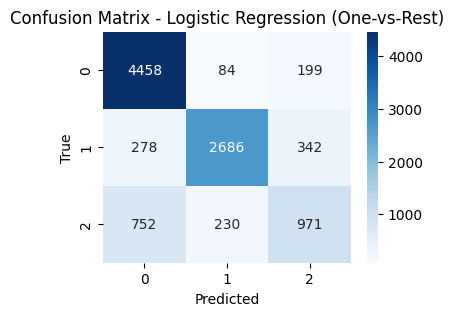


--- Logistic Regression (One-vs-One) ---
Accuracy: 0.8153
F1-Macro Score: 0.7725


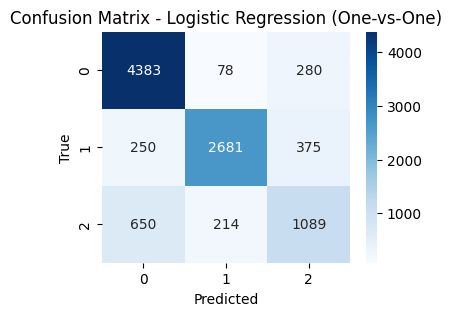


--- SVM ---
Accuracy: 0.8125
F1-Macro Score: 0.7734


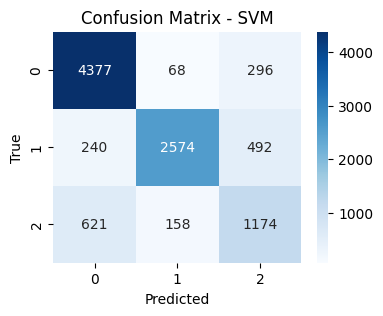


--- KNN ---
Accuracy: 0.7816
F1-Macro Score: 0.7318


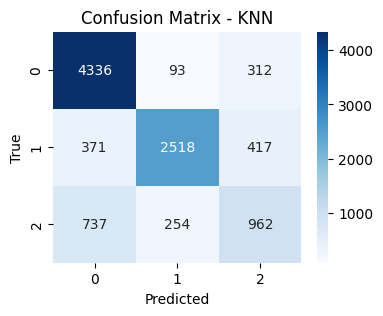


--- Random Forest ---
Accuracy: 0.8172
F1-Macro Score: 0.7768


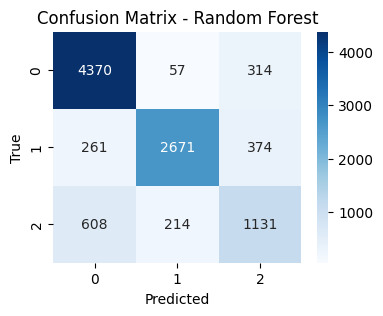


--- Decision Tree ---
Accuracy: 0.8020
F1-Macro Score: 0.7690


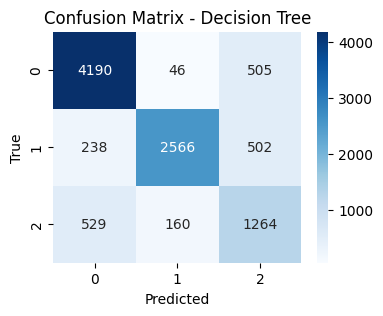


--- Gradient Boosting ---
Accuracy: 0.8217
F1-Macro Score: 0.7828


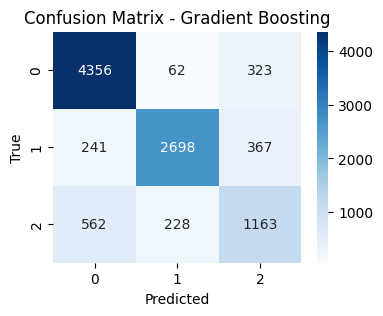


--- Voting (soft) ---
Accuracy: 0.8196
F1-Macro Score: 0.7772


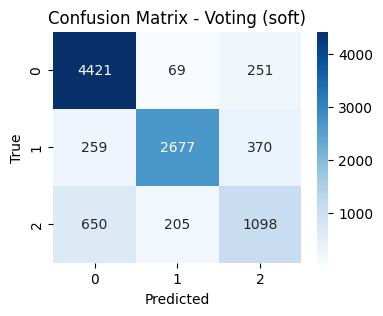


--- Model Performance Summary ---
                                   Accuracy  F1-Macro  Precision-Macro
Model                                                                 
Logistic Regression (One-vs-Rest)    0.8115  0.761329         0.783282
Logistic Regression (One-vs-One)     0.8153  0.772528         0.785284
SVM                                  0.8125  0.773364         0.784426
KNN                                  0.7816  0.731838         0.748083
Random Forest                        0.8172  0.776809         0.787928
Decision Tree                        0.8020  0.768979         0.775846
Gradient Boosting                    0.8217  0.782822         0.791642
Voting (soft)                        0.8196  0.777229         0.791783


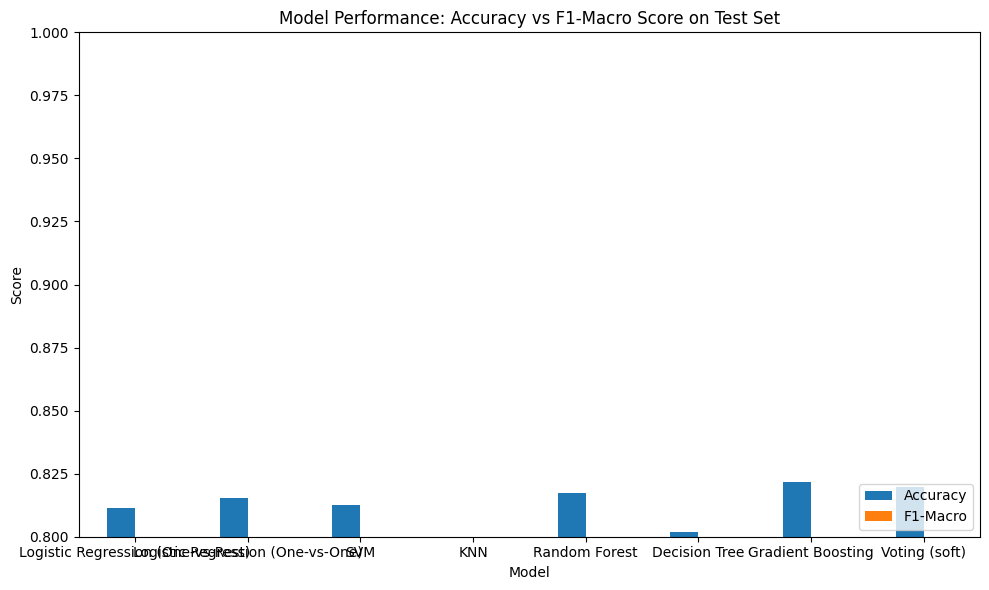

In [47]:
results = []

print("Evaluating models on the test set...")
for name, model in models.items():
    y_pred_eval = model.predict(X_test)
    y_true = y_test

    accuracy = accuracy_score(y_true, y_pred_eval)
    f1_macro = f1_score(y_true, y_pred_eval, average='macro')

    # Calculate precision for each class and then macro average
    precision_macro = precision_score(y_true, y_pred_eval, average='macro')

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'F1-Macro': f1_macro,
        'Precision-Macro': precision_macro
    })

    print(f"\n--- {name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-Macro Score: {f1_macro:.4f}")

    # Confusion Matrix
    cm_model = confusion_matrix(y_true, y_pred_eval)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm_model, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()


results_df = pd.DataFrame(results)
print("\n--- Model Performance Summary ---")
print(results_df.set_index('Model'))

# Plotting Accuracy and F1-Macro Scores
fig, ax = plt.subplots(figsize=(10, 6))
results_df.set_index('Model')[['Accuracy', 'F1-Macro']].plot(kind='bar', ax=ax, rot=0)
ax.set_title('Model Performance: Accuracy vs F1-Macro Score on Test Set')
ax.set_ylabel('Score')
ax.set_ylim(0.8, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()